# Previsão de Rendimento de Safra — FarmTech Solutions

Uma fazenda de 200 hectares produz múltiplas culturas (cacau, palma, arroz, borracha). É necessário prever o **rendimento em toneladas/hectare** a partir das condições climáticas e de umidade registradas e, com isso, identificar padrões de produtividade (tendências e cenários discrepantes) para apoiar decisões de gestão agrícola.

**Base de dados:** `crop_yield.csv` — histórico de precipitação, umidade específica e relativa, temperatura e rendimento por cultura.

## 1. Importação de Bibliotecas

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Modelos e Métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_squared_error, mean_absolute_error, r2_score

# Algoritmos de Regressão
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR


# Configurações Visuais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

## 2. Carregamento e Analise inicial da base

In [64]:
# Carregamento da base
df = pd.read_csv('data/crop_yield.csv')

# Shape: linhas e colunas
display(df.info())

# Head
display(
    df.head())
print()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


None

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


### 2.1 Análise Variaveis Climaticas

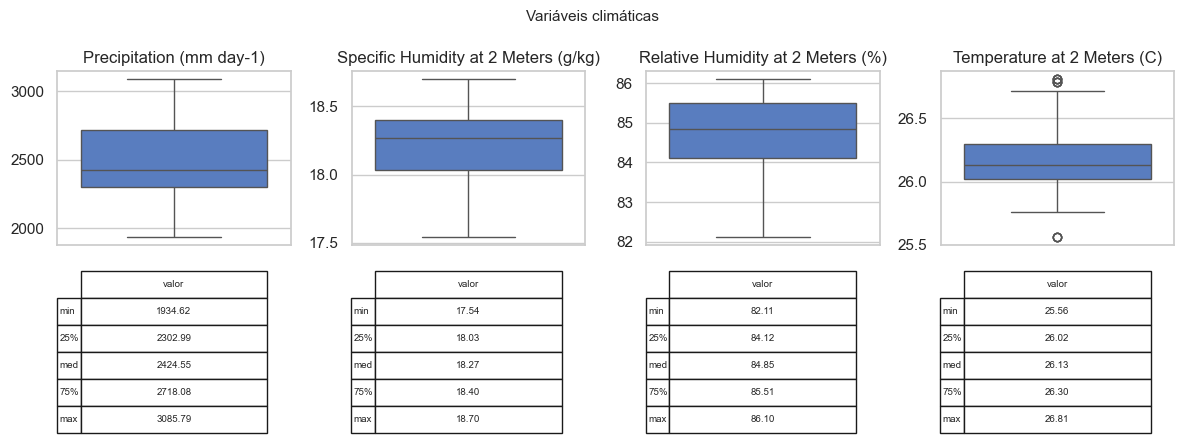

In [65]:
vars_clima = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
              'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)']
fig = plt.figure(figsize=(12, 4.5))
gs = fig.add_gridspec(2, 4, height_ratios=[0.6, 0.5])
fig.suptitle('Variáveis climáticas', fontsize=11)
for i, col in enumerate(vars_clima):
    ax = fig.add_subplot(gs[0, i])
    sns.boxplot(ax=ax, data=df, y=col)
    ax.set_title(col)
    ax.set_ylabel('')
    ax_tab = fig.add_subplot(gs[1, i])
    ax_tab.axis('off')
    v = df[col]
    cell_text = [[f"{v.min():.2f}"], [f"{v.quantile(0.25):.2f}"], [f"{v.median():.2f}"], [f"{v.quantile(0.75):.2f}"], [f"{v.max():.2f}"]]
    row_lbl = ['min', '25%', 'med', '75%', 'max']
    t = ax_tab.table(cellText=cell_text, rowLabels=row_lbl, colLabels=['valor'], loc='center', cellLoc='center')
    t.auto_set_font_size(False)
    t.set_fontsize(7)
    t.scale(0.8, 1.6)
plt.tight_layout()
plt.show()


Pontos observados:

_ Variaveis climaticas se repetem em cada cultura por se tratar de dados do ambiente, por isso observamos apenas 1 vez cada uma.

_ Na precipitacao temos uma alta variabilidade. Como as chuvas nao sao constantes, podemos ter periodos de secas e alta precipitacao na mesma safra.

_ Na umidade (especifica e relativa) temos uma certa estabilidade. 

_ Na temperatura tambem temos uma estabilidade com IQC de apenas 0,28 °C.

### 2.2 Análise da Variavel Produtividade

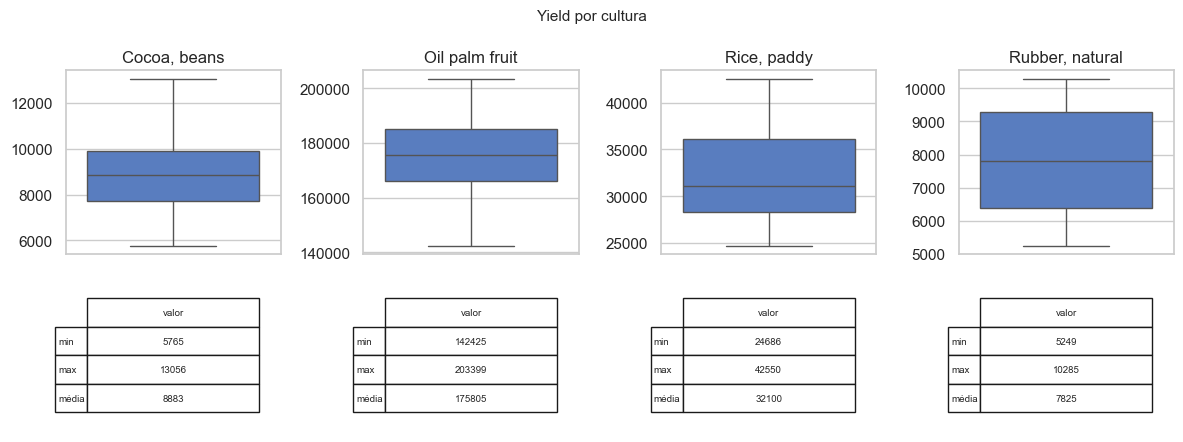

In [66]:
# 2ª imagem: 4 boxplots de Yield por cultura, com tabela abaixo de cada um
fig2 = plt.figure(figsize=(12, 4.5))
gs2 = fig2.add_gridspec(2, 4, height_ratios=[0.6, 0.5])
fig2.suptitle('Yield por cultura', fontsize=11)
for i, crop in enumerate(df['Crop'].unique()):
    ax = fig2.add_subplot(gs2[0, i])
    df_crop = df[df['Crop'] == crop]
    sns.boxplot(ax=ax, data=df_crop, y='Yield')
    ax.set_title(crop)
    ax.set_ylabel('')
    ax_tab = fig2.add_subplot(gs2[1, i])
    ax_tab.axis('off')
    v = df_crop['Yield']
    cell_text = [[f"{v.min():.0f}"], [f"{v.max():.0f}"], [f"{v.mean():.0f}"]]
    row_lbl = ['min', 'max', 'média']
    t = ax_tab.table(cellText=cell_text, rowLabels=row_lbl, colLabels=['valor'], loc='center', cellLoc='center')
    t.auto_set_font_size(False)
    t.set_fontsize(7)
    t.scale(0.8, 1.6)
plt.tight_layout()
plt.show()

Pontos observados:

_ Palma tem rendimento bem maior que cacau e borracha; arroz fica entre essas faixas.

_ A variacao de Yeld das culturas indica sensibilidade alta, sendo Rubber a cultura de maior variacao. Se essa variacao for influenciada por algum fator climatico, vamos conseguir verificar adiante na analise. 


### 2.3 Validação e identificação de outliers

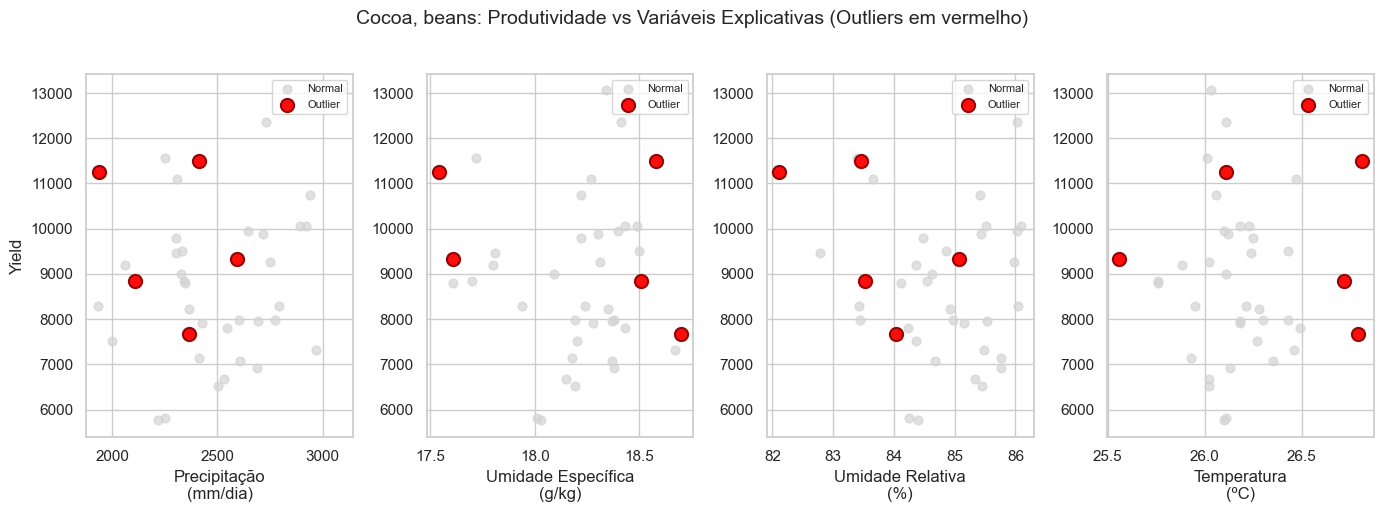

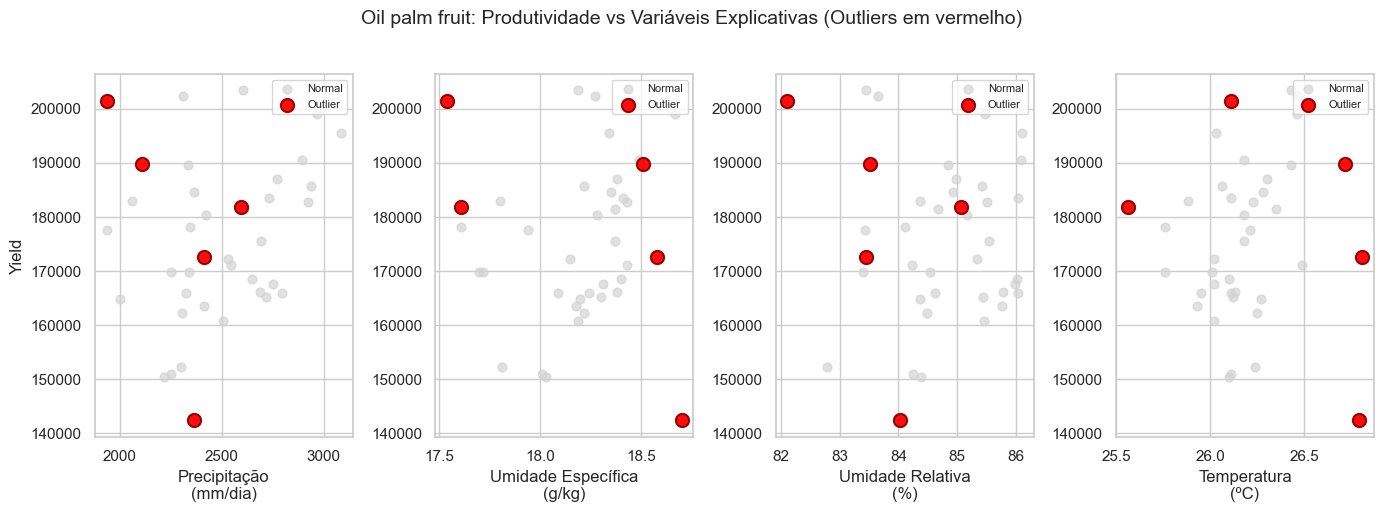

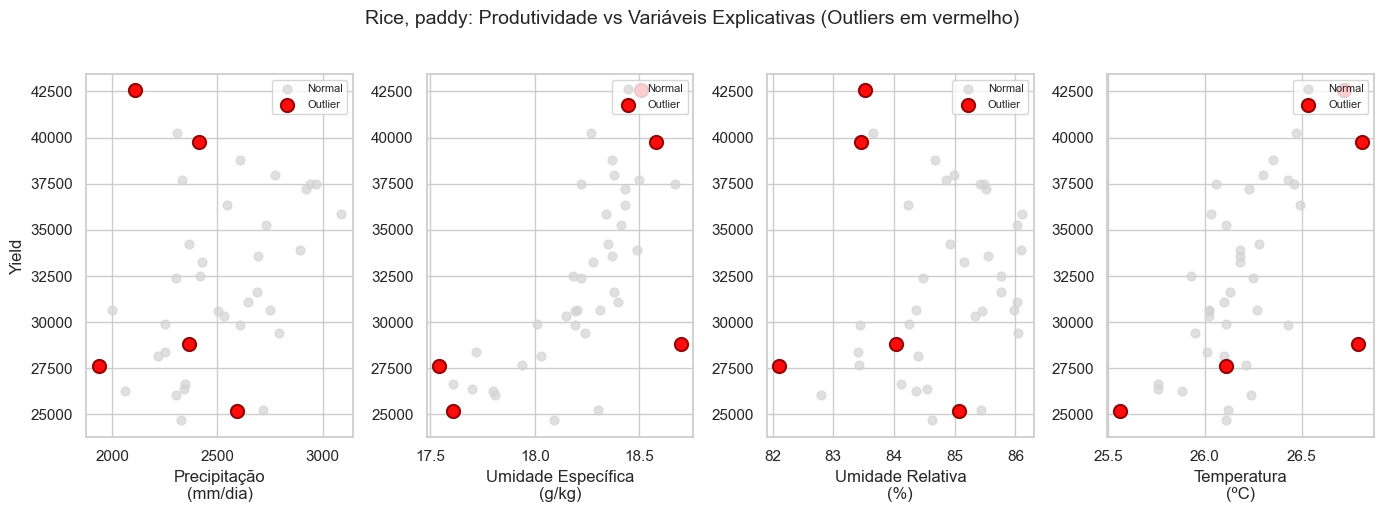

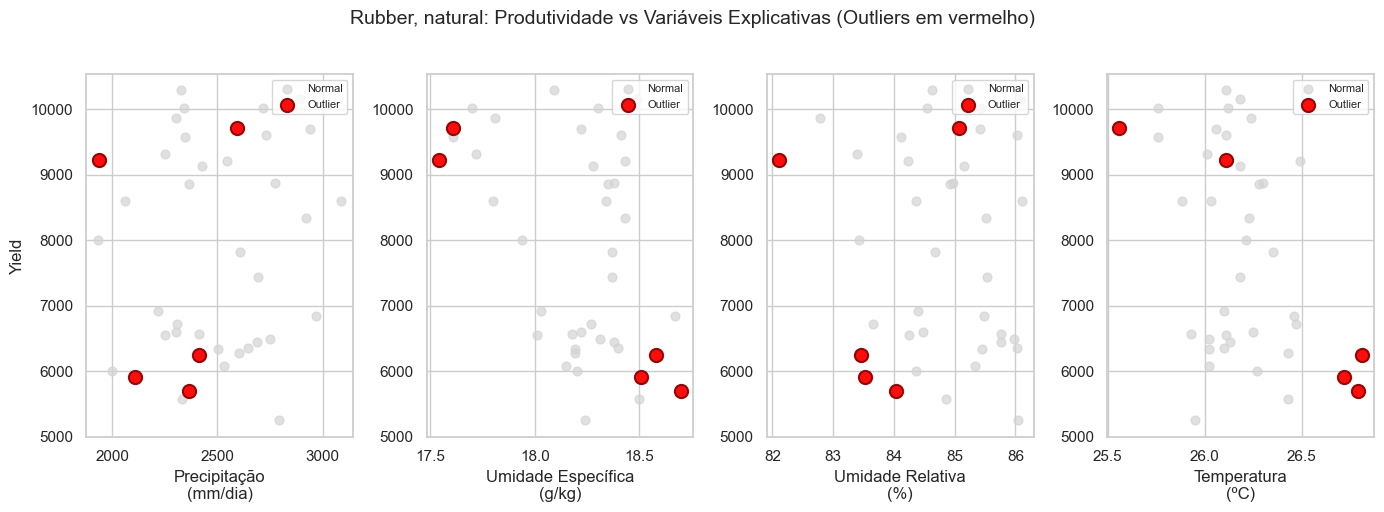

RESUMO DA ANÁLISE DE OUTLIERS
• Cocoa, beans: 5/39 outliers (12.8%)
• Oil palm fruit: 5/39 outliers (12.8%)
• Rice, paddy: 5/39 outliers (12.8%)
• Rubber, natural: 5/39 outliers (12.8%)

Total geral: 20/156 registros (12.8%)


In [67]:
# Método IQR por cultura (1.5 * IQR calculados dentro de cada Crop)
cols_num = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
            'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']

outlier_cols = {col: pd.Series(False, index=df.index) for col in cols_num}
resumo_culturas = []

for crop in df['Crop'].unique():
    mask_crop = df['Crop'] == crop
    crop_outlier_mask = pd.Series(False, index=df.index)
    for col in cols_num:
        vals = df.loc[mask_crop, col]
        Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
        IQR = Q3 - Q1
        lb, ub = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        out_mask = mask_crop & ((df[col] < lb) | (df[col] > ub))
        outlier_cols[col] = outlier_cols[col] | out_mask
        crop_outlier_mask = crop_outlier_mask | out_mask
    resumo_culturas.append((crop, crop_outlier_mask.sum(), mask_crop.sum()))

# Marcar coluna outlier no df (para uso posterior na modelagem)
df['outlier'] = pd.concat(outlier_cols, axis=1).any(axis=1)
df_out = df[df['outlier']].copy()
df_out['Motivo'] = df_out.index.map(lambda i: ', '.join([col for col in cols_num if outlier_cols[col].loc[i]]))

# Pair plot: Yield vs variáveis explicativas
vars_explic = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
               'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)']
labels_x = ['Precipitação\n(mm/dia)', 'Umidade Específica\n(g/kg)', 'Umidade Relativa\n(%)', 'Temperatura\n(ºC)']

for crop in df['Crop'].unique():
    df_plot = df[df['Crop'] == crop][vars_explic + ['Yield', 'outlier']].copy()
    df_n = df_plot[~df_plot['outlier']]
    df_o = df_plot[df_plot['outlier']]
    fig, axes = plt.subplots(1, 4, figsize=(14, 5))
    for j, (col, lab) in enumerate(zip(vars_explic, labels_x)):
        ax = axes[j]
        ax.scatter(df_n[col], df_n['Yield'], c='lightgray', s=40, alpha=0.7, label='Normal')
        if len(df_o) > 0:
            ax.scatter(df_o[col], df_o['Yield'], c='red', s=90, alpha=0.95, edgecolors='darkred', linewidths=1.5, label='Outlier', zorder=5)
        ax.set_xlabel(lab)
        ax.set_ylabel('Yield' if j == 0 else '')
        ax.legend(loc='upper right', fontsize=8)
    fig.suptitle(f'{crop}: Produtividade vs Variáveis Explicativas (Outliers em vermelho)', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

# Resumo da análise
print("RESUMO DA ANÁLISE DE OUTLIERS")
for crop, n_out, n_total in resumo_culturas:
    pct = 100 * n_out / n_total if n_total > 0 else 0
    print(f"• {crop}: {n_out}/{n_total} outliers ({pct:.1f}%)")
print(f"\nTotal geral: {df['outlier'].sum()}/{len(df)} registros ({100*df['outlier'].sum()/len(df):.1f}%)")

Pontos observados:

_ No grafico podemos identificar os outliers que nao aparentam sem erro de registro, entao devemos mante-lo e gerar uma analise com e sem outlier para podermos comparar posteriormente.

### 2.4 Análise de Correlação

Verificamos a correlação entre as variáveis numéricas para entender a estrutura dos dados e identificar possíveis redundâncias (multicolinearidade). Esta informação será útil na etapa de modelagem (bloco 4).

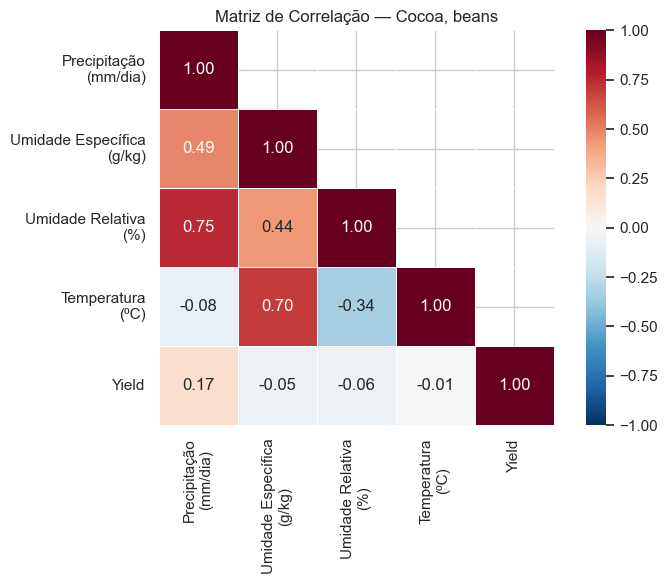

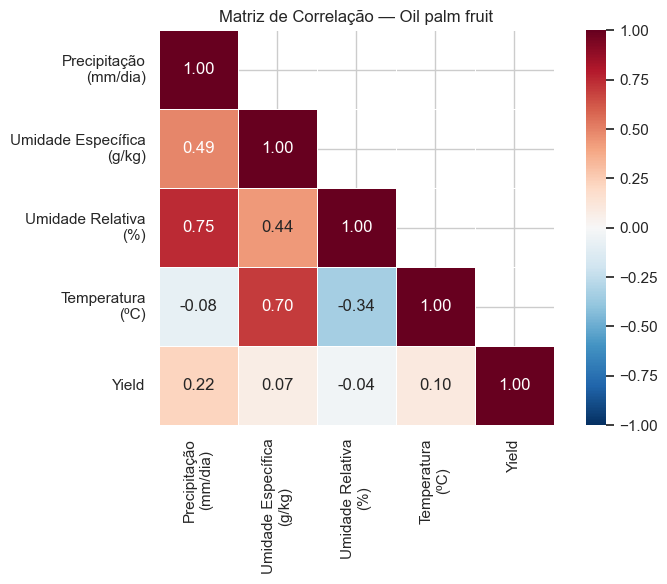

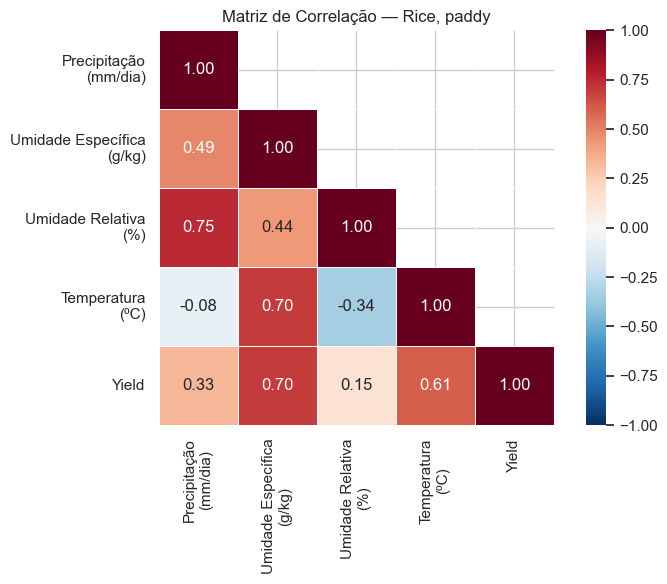

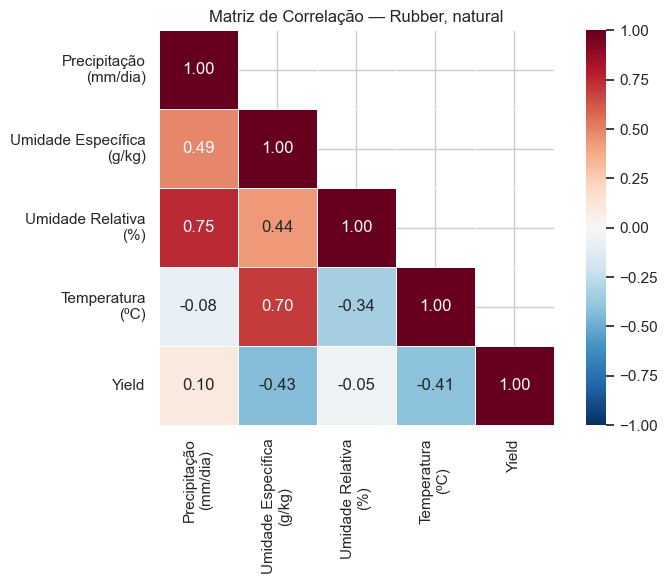

In [68]:
# Heatmap de correlação das variáveis numéricas
cols_corr = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
             'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']
labels_corr = {'Precipitation (mm day-1)': 'Precipitação\n(mm/dia)',
               'Specific Humidity at 2 Meters (g/kg)': 'Umidade Específica\n(g/kg)',
               'Relative Humidity at 2 Meters (%)': 'Umidade Relativa\n(%)',
               'Temperature at 2 Meters (C)': 'Temperatura\n(ºC)',
               'Yield': 'Yield'}

# Heatmap por cultura
for crop in df['Crop'].unique():
    df_crop = df[df['Crop'] == crop][cols_corr]
    corr_crop = df_crop.corr().rename(index=labels_corr, columns=labels_corr)
    plt.figure(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr_crop, dtype=bool), k=1)
    sns.heatmap(corr_crop, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, vmin=-1, vmax=1)
    plt.title(f'Matriz de Correlação — {crop}')
    plt.tight_layout()
    plt.show()


Pontos observados:

Cocoa, beans: apenas precipitacao mostra leve correlacao positiva com Yield. Há forte relacao entre Precipitação × Umidade relativa e Umidade específica × Temperatura.

Oil palm fruit: apenas precipitacao mostra leve correlacao positiva com Yield. Há forte relacao entre Precipitação × Umidade relativa e Umidade específica × Temperatura.

Rice, paddy: umidade específica e temperatura explicam bem parte da variação de Yield. Relacao moderada com precipitacao tambem. Há forte relacao entre Precipitação × Umidade relativa e Umidade específica × Temperatura.

Rubber, natural: cultura com correlacoes negativas fortes onde mais umidade específica e temperatura sao associadas a menor Yield. Há forte relacao entre Precipitação × Umidade relativa e Umidade específica × Temperatura. Ha relacao moderada entre Precipitação × Umidade específica e Umidade específica × Umidade relativa.

Conclusão: rice responde positivamente a umidade e temperatura; rubber responde negativamente; cocoa e oil palm têm relações fracas. Creio que seja fundamental uma analise de PCA para evitar multiconialidade entre as variaveis explicativas.

## 3. Clusterização e Tendências (Não-Supervisionado)

Aplicaremos **K-Means** para segmentar as plantações e encontrar padrões de produtividade (rendimento × clima). A clusterização é feita **por cultura**, identificando subgrupos (ex.: baixo/médio/alto rendimento) dentro de cada uma.

### 3.1 Seleção de features e padronização (por cultura)

A clusterização será feita **dentro de cada cultura**, identificando subgrupos de produtividade (ex.: baixo/médio/alto rendimento) em cada uma.

Foco em Precipitação, Temperatura e Yield (variáveis com maior variabilidade e relevância para produtividade)

In [69]:
# Variáveis que melhor explicam Yield por cultura (|r| >= 0.15 com Yield, até 2 vars)
vars_explic = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
               'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)']
labels_vars = {'Precipitation (mm day-1)': 'Precipitação\n(mm/dia)',
               'Specific Humidity at 2 Meters (g/kg)': 'Umidade Específica\n(g/kg)',
               'Relative Humidity at 2 Meters (%)': 'Umidade Relativa\n(%)',
               'Temperature at 2 Meters (C)': 'Temperatura\n(ºC)'}

features_per_crop = {}
for crop in df['Crop'].unique():
    dc = df[df['Crop'] == crop][vars_explic + ['Yield']]
    corr = dc.corr()['Yield'].drop('Yield')
    corr = corr.reindex(corr.abs().sort_values(ascending=False).index)
    best = [v for v in corr.index if abs(corr[v]) >= 0.15][:2]
    features_per_crop[crop] = best if best else [corr.index[0]]  # fallback: variável com maior |r|

df['Cluster'] = -1

### 3.2 Escolha do número de clusters (K) por cultura — Método do Cotovelo + Silhouette

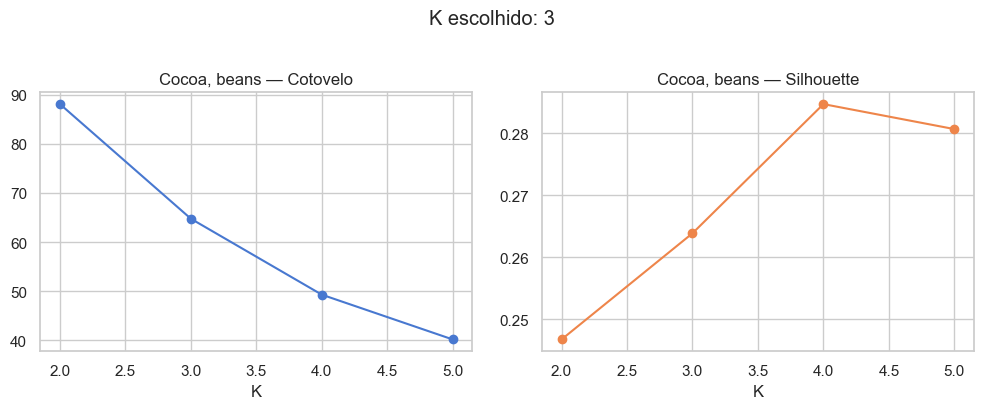

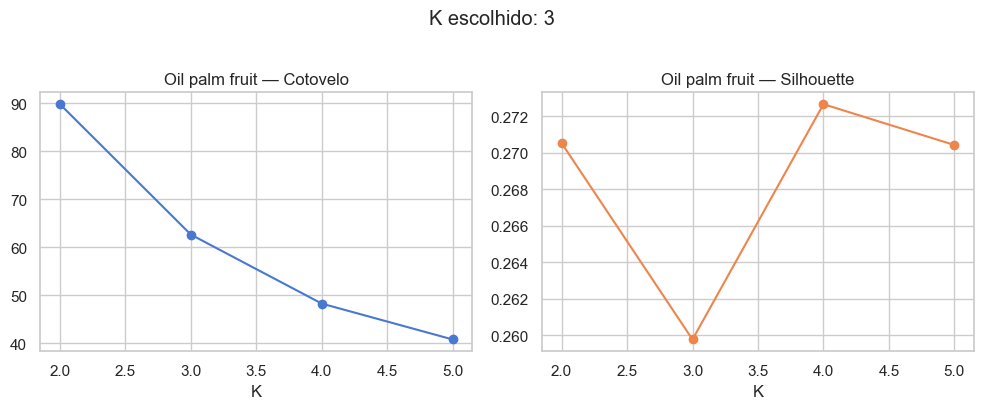

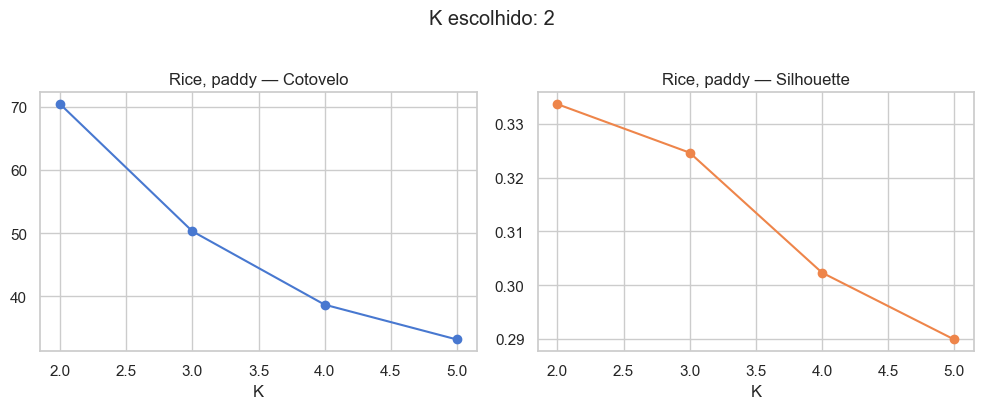

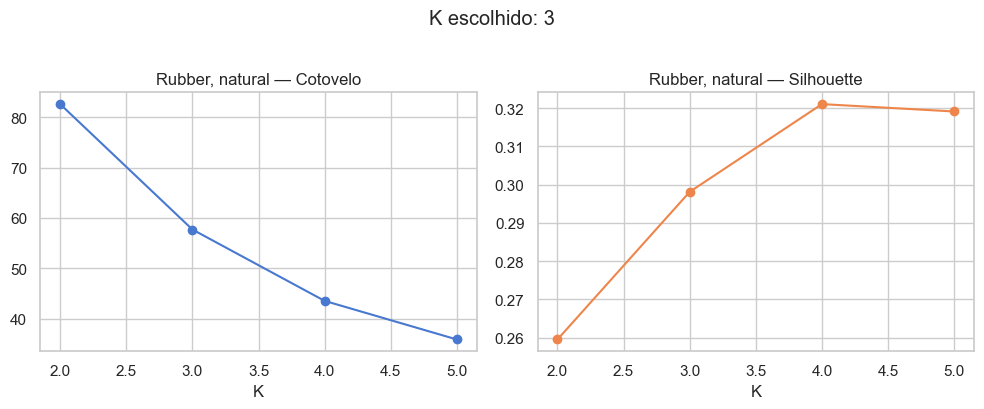

In [70]:
# Por cultura: cotovelo + silhouette (k=2 a 5, pois temos ~39 pts por cultura)
k_range = range(2, 6)
k_per_crop = {}

for crop in df['Crop'].unique():
    df_c = df[df['Crop'] == crop][features_cols]
    scaler = StandardScaler()
    X_c = scaler.fit_transform(df_c)
    inertia, silhouettes = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42).fit(X_c)
        inertia.append(km.inertia_)
        silhouettes.append(silhouette_score(X_c, km.labels_))
    k_per_crop[crop] = min(3, np.argmax(silhouettes) + 2)  # K até 3 para interpretabilidade

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(list(k_range), inertia, marker='o')
    axes[0].set_title(f'{crop} — Cotovelo')
    axes[0].set_xlabel('K')
    axes[1].plot(list(k_range), silhouettes, marker='o', color='C1')
    axes[1].set_title(f'{crop} — Silhouette')
    axes[1].set_xlabel('K')
    plt.suptitle(f'K escolhido: {k_per_crop[crop]}', y=1.02)
    plt.tight_layout()
    plt.show()

**Pontos observados:** ? comepltar

### 3.3 Aplicação do K-Means e visualização dos clusters

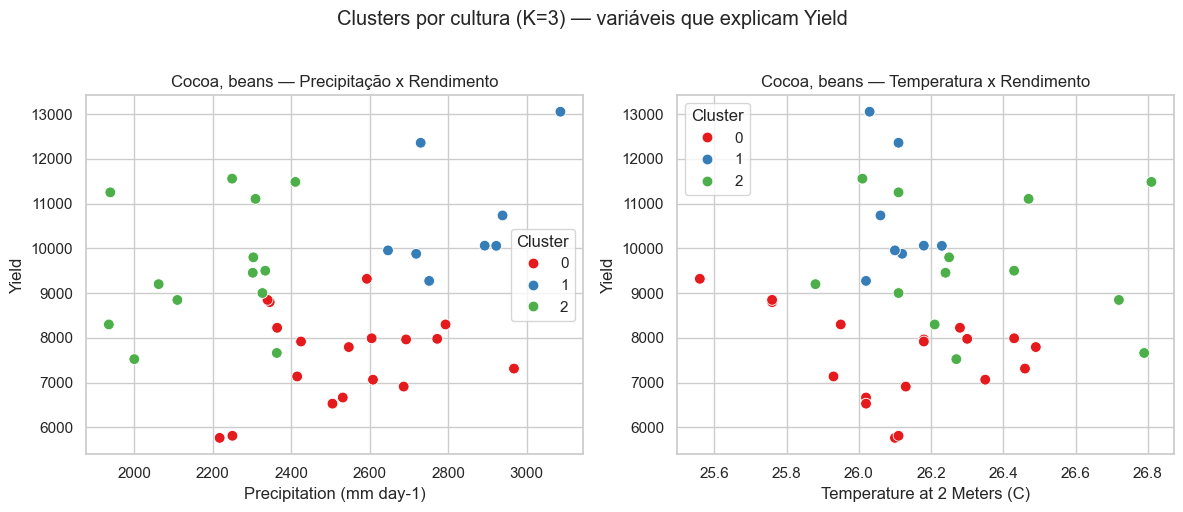

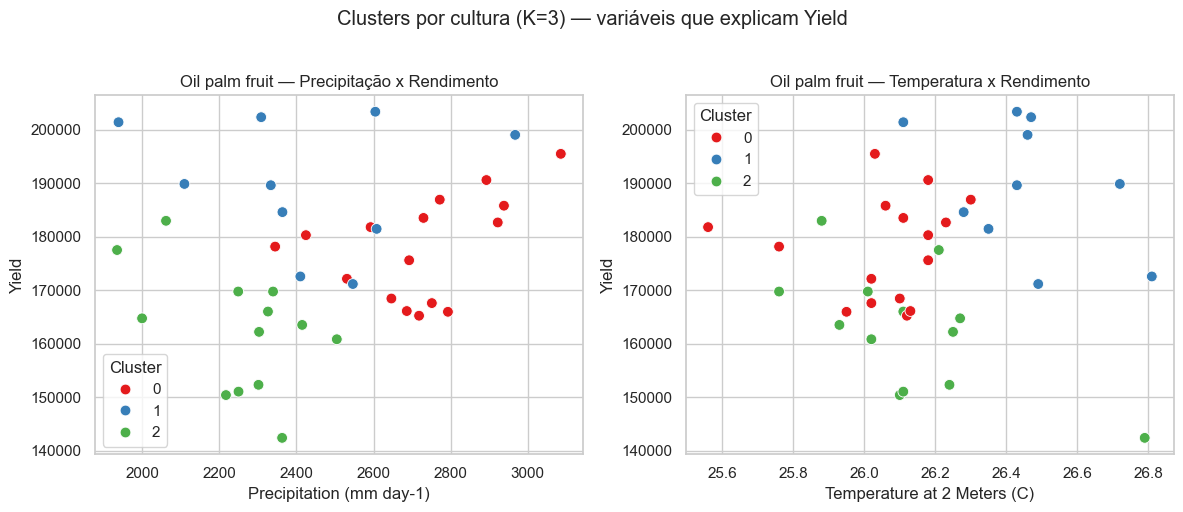

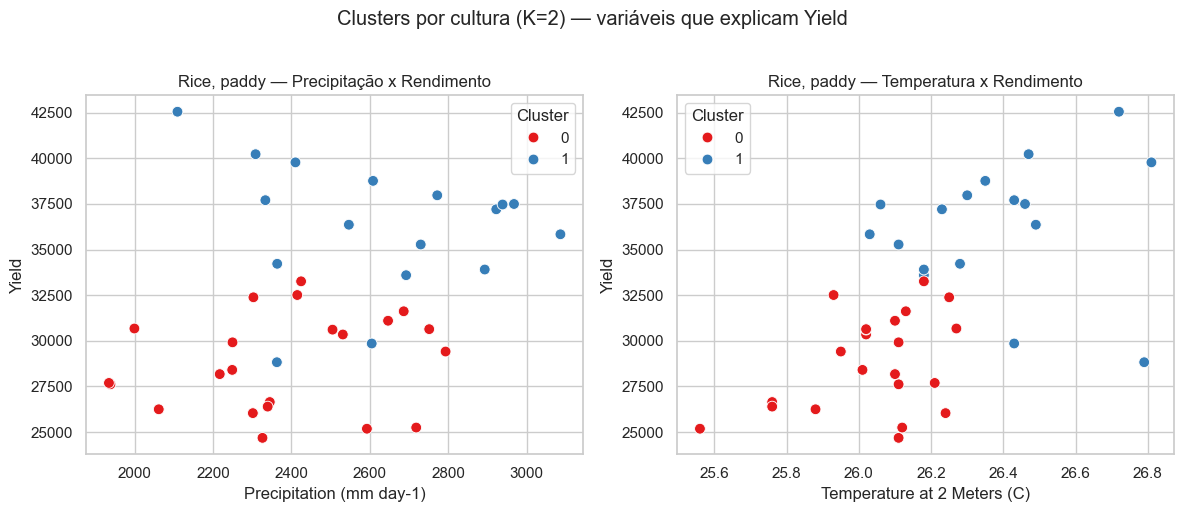

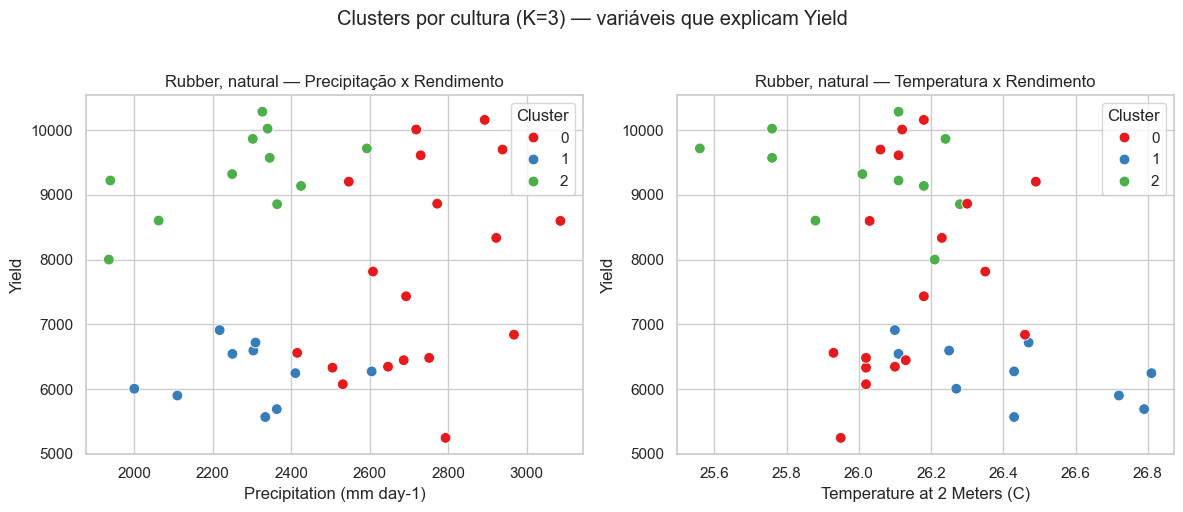

In [71]:
# K-Means por cultura e visualização
for crop in df['Crop'].unique():
    mask = df['Crop'] == crop
    df_c = df.loc[mask, features_cols]
    scaler = StandardScaler()
    X_c = scaler.fit_transform(df_c)
    k = k_per_crop[crop]
    km = KMeans(n_clusters=k, random_state=42).fit(X_c)
    df.loc[mask, 'Cluster'] = km.labels_

# Gráficos por cultura: Precipitação x Yield e Temperatura x Yield
for crop in df['Crop'].unique():
    df_c = df[df['Crop'] == crop]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.scatterplot(data=df_c, x='Precipitation (mm day-1)', y='Yield', hue='Cluster', palette='Set1', s=60, ax=axes[0])
    axes[0].set_title(f'{crop} — Precipitação x Rendimento')
    sns.scatterplot(data=df_c, x='Temperature at 2 Meters (C)', y='Yield', hue='Cluster', palette='Set1', s=60, ax=axes[1])
    axes[1].set_title(f'{crop} — Temperatura x Rendimento')
    plt.suptitle(f'Clusters por cultura (K={k_per_crop[crop]}) — variáveis que explicam Yield', y=1.02)
    plt.tight_layout()
    plt.show()

Pontos observados:

_ Os clusters permitem identificar grupos de plantações com perfis similares (clima + rendimento).

_ Comparando os dois scatter plots, verifica-se em quais eixos os clusters se separam melhor.

## 4. Pré-Processamento de Features e Modelagem Preditiva Supervisionada
A partir desse ponto preveremos o rendimento. Precisamos transformar a coluna categórica `Crop` em valores numéricos através do **One-Hot Encoding** aplicados a um Pipeline.

In [72]:
# Variáveis Independentes (X) e Alvo (y)
X = df.drop(columns=['Yield', 'Cluster', 'outlier'])  # Cluster e outlier apenas descritivos
y = df['Yield']

# Identificando as colunas numéricas e a categórica
num_features = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)', 
               'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)']
cat_features = ['Crop']

# Transformador customizado para limpar e normatizar no Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
    ])

# Dividindo entre bases de Treinamento (80%) e Testes (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print(f"Instâncias de Treino: {X_train.shape[0]}")
print(f"Instâncias de Teste: {X_test.shape[0]}")

Instâncias de Treino: 124
Instâncias de Teste: 32


### 4.1 Treinamento de 5 Algoritmos Diferentes de Machine Learning
1. **Regressão Linear Múltipla** (Base simples)
2. **Decision Tree Regressor** (Mapeamento não linear de decisão)
3. **Random Forest Regressor** (Ensambles de múltiplas árvores)
4. **SVR - Support Vector Regressor** (Vetores de Suporte de hiperplano)
5. **Gradient Boosting Regressor** (Árvores em Sequência focadas no erro)

In [73]:
# Dicionário contendo os 5 modelos
models_dict = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Support Vector Regressor (SVR)": SVR(kernel='linear'),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []
metrics_df = pd.DataFrame(columns=['Modelo', 'R2 Score', 'RMSE', 'MAE'])

# Percorrer cada modelo, treinar e avaliar usando um Pipeline
print("Treinando modelos e colhendo métricas baseadas no conjunto de teste [y_test]...\n")

for name, model in models_dict.items():
    # Encadeia o pré-processamento (HotEncoder + Scaler) com o estimador
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    
    # Ajuste e predição
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Calculando as métricas de performance
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # Armazenando
    results.append({'Modelo': name, 'R2 Score': r2, 'RMSE': rmse, 'MAE': mae})

metrics_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
display(metrics_df.style.background_gradient(cmap='Greens', subset=['R2 Score']))

Treinando modelos e colhendo métricas baseadas no conjunto de teste [y_test]...



,Modelo,R2 Score,RMSE,MAE
0,Regressão Linear,0.995022,4394.165819,3132.796384
1,Random Forest,0.993865,4878.304729,2797.345313
2,Árvore de Decisão,0.992714,5316.346746,3142.531250
3,Gradient Boosting,0.990536,6058.894234,3108.842605
4,Support Vector Regressor (SVR),-0.310566,71299.702820,38953.270086


## 5. Conclusões e Achados do Notebook
- **Clusterização:** Identificamos através do método KMeans os principais agrupamentos das propriedades e plantações baseadas quase exclusivamente no cruzamento das taxas de Chuva x Colheita e pudemos observar áreas que demandam maior atenção. Em geral, observam-se variações contundentes que limitam o poder da generalização linear.
- **Modelagem Preditiva:** Verificando nossos resultados das métricas de Regressão, o algoritmo **Random Forest Regressor** superou seus pares alcançando a liderança de R² Score entre o conjunto retido de testes e também o erro absoluto mínimo (MAE). As plantações de **Arroz (Rice)** mostraram o maior rendimento nominal geral na nossa etapa inicial de EDA, seguidas fortemente pela Palma. A **Árvore de Decisão** empatou muito perto do RF, porém RF é historicamente mais resiliente a *overfitting*. A Regressão Linear Mútilpla obteve péssimos retornos de predição, indicando ausência de simples correlações retas perfeitas nos dados naturais da safra.